# Geographic and Crash Severity Analysis

## Beyond the Crash Count

This notebook investigates how reported crash frequency and serious
crash outcomes vary geographically across North Carolina.

The analysis focuses on the five complete calendar years from
2021 through 2025.

### Primary questions

1. Where are the largest numbers of reported crashes recorded?
2. Where are serious crash outcomes relatively more common among
   recorded crashes?
3. Do areas with high crash frequency necessarily have high crash
   severity?
4. How do crash outcomes differ between records classified as rural
   and municipal/city?

### Primary severity metric

A **serious crash** is defined as an NCDOT severity `K` (fatal) or
`A` (serious/disabling injury) crash.

The **Serious Outcome Rate** is:

> K+A crashes per 1,000 recorded crashes with known severity.

Records coded `U` (unknown severity) are retained in the source data
but excluded from the denominator.

### Interpretation

This metric describes severity among recorded crashes. It should not
be interpreted as the probability of crashing or as a complete measure
of roadway danger because the dataset does not currently include an
exposure measure such as vehicle miles traveled.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "src").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "src").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise RuntimeError(
        "Could not locate the project root containing the src/ directory."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import load_crash_data
from src.metrics import (
    known_severity_crash_count,
    serious_crash_count,
    serious_rate_per_1000,
)

In [2]:
df = load_crash_data()

statewide_serious_rate = serious_rate_per_1000(df)

print(f"Crash records: {len(df):,}")
print(
    f"Analysis period: "
    f"{df['Year'].min()}–{df['Year'].max()}"
)
print(f"Counties represented: {df['County'].nunique()}")
print(
    f"NC Serious Outcome Rate: "
    f"{statewide_serious_rate:.2f} per 1,000 known-severity crashes"
)

Crash records: 1,535,119
Analysis period: 2021–2025
Counties represented: 100
NC Serious Outcome Rate: 19.88 per 1,000 known-severity crashes


In [3]:
county_values = (
    df["County"]
    .value_counts(dropna=False)
    .rename_axis("County")
    .reset_index(name="crash_count")
)

county_values

,County,crash_count
0,Mecklenburg,201315
1,Wake,175360
2,Guilford,74993
3,Forsyth,66410
4,Durham,55149
...,...,...
95,Alleghany,969
96,Gates,919
97,Graham,838
98,Tyrrell,515


In [4]:
print(f"Unique County values: {df['County'].nunique(dropna=False)}")
print(f"Missing County values: {df['County'].isna().sum():,}")

Unique County values: 100
Missing County values: 0


In [5]:
sorted(
    df["County"]
    .dropna()
    .astype(str)
    .unique()
)

['Alamance',
 'Alexander',
 'Alleghany',
 'Anson',
 'Ashe',
 'Avery',
 'Beaufort',
 'Bertie',
 'Bladen',
 'Brunswick',
 'Buncombe',
 'Burke',
 'Cabarrus',
 'Caldwell',
 'Camden',
 'Carteret',
 'Caswell',
 'Catawba',
 'Chatham',
 'Cherokee',
 'Chowan',
 'Clay',
 'Cleveland',
 'Columbus',
 'Craven',
 'Cumberland',
 'Currituck',
 'Dare',
 'Davidson',
 'Davie',
 'Duplin',
 'Durham',
 'Edgecombe',
 'Forsyth',
 'Franklin',
 'Gaston',
 'Gates',
 'Graham',
 'Granville',
 'Greene',
 'Guilford',
 'Halifax',
 'Harnett',
 'Haywood',
 'Henderson',
 'Hertford',
 'Hoke',
 'Hyde',
 'Iredell',
 'Jackson',
 'Johnston',
 'Jones',
 'Lee',
 'Lenoir',
 'Lincoln',
 'Macon',
 'Madison',
 'Martin',
 'Mcdowell',
 'Mecklenburg',
 'Mitchell',
 'Montgomery',
 'Moore',
 'Nash',
 'New Hanover',
 'Northampton',
 'Onslow',
 'Orange',
 'Pamlico',
 'Pasquotank',
 'Pender',
 'Perquimans',
 'Person',
 'Pitt',
 'Polk',
 'Randolph',
 'Richmond',
 'Robeson',
 'Rockingham',
 'Rowan',
 'Rutherford',
 'Sampson',
 'Scotland',
 '

In [6]:
area_summary = (
    df["area_type"]
    .value_counts(dropna=False)
    .rename_axis("area_type")
    .reset_index(name="crash_count")
)

area_summary["percent"] = (
    area_summary["crash_count"] / len(df) * 100
)

area_summary

,area_type,crash_count,percent
0,Municipal/City,994277,64.768725
1,Rural,537865,35.037349
2,Unknown,2977,0.193926


In [7]:
from src.geography import (
    build_county_summary,
    prepare_county_geodata,
    validate_county_coverage,
)

In [ ]:
%pip install geopandas

In [8]:
county_summary = build_county_summary(df)

county_summary.head(10)

,County,crash_count,known_severity_count,serious_crash_count,serious_rate_per_1000,severity_multiplier,rural_crash_count,rural_crash_share
0,Mecklenburg,201315,191119,1509,7.895604,0.397093,737,0.003661
1,Wake,175360,169781,2252,13.264146,0.667093,34081,0.194349
2,Guilford,74993,72975,846,11.593011,0.583046,11900,0.158681
3,Forsyth,66410,63250,1057,16.711462,0.840468,4274,0.064358
4,Durham,55149,52598,605,11.502338,0.578486,8279,0.150121
5,Cumberland,48084,46237,1192,25.780219,1.296562,12145,0.252579
6,Buncombe,40733,39357,456,11.586249,0.582706,14534,0.356811
7,Gaston,38668,37420,553,14.778193,0.743238,8343,0.215760
8,New Hanover,32103,30877,364,11.788710,0.592889,10766,0.335358
9,Johnston,31527,30384,735,24.190363,1.216604,21044,0.667491


In [9]:
validate_county_coverage(county_summary)

county_analysis = county_summary.copy()

county_analysis[
    [
        "County",
        "crash_count",
        "rural_crash_count",
        "rural_crash_share",
        "serious_crash_count",
        "serious_rate_per_1000",
        "severity_multiplier",
    ]
].head(10)

,County,crash_count,rural_crash_count,rural_crash_share,serious_crash_count,serious_rate_per_1000,severity_multiplier
0,Mecklenburg,201315,737,0.003661,1509,7.895604,0.397093
1,Wake,175360,34081,0.194349,2252,13.264146,0.667093
2,Guilford,74993,11900,0.158681,846,11.593011,0.583046
3,Forsyth,66410,4274,0.064358,1057,16.711462,0.840468
4,Durham,55149,8279,0.150121,605,11.502338,0.578486
5,Cumberland,48084,12145,0.252579,1192,25.780219,1.296562
6,Buncombe,40733,14534,0.356811,456,11.586249,0.582706
7,Gaston,38668,8343,0.215760,553,14.778193,0.743238
8,New Hanover,32103,10766,0.335358,364,11.788710,0.592889
9,Johnston,31527,21044,0.667491,735,24.190363,1.216604


In [10]:
county_summary.sort_values(
    "serious_rate_per_1000",
    ascending=False
).head(15)

,County,crash_count,known_severity_count,serious_crash_count,serious_rate_per_1000,severity_multiplier,rural_crash_count,rural_crash_share
97,Graham,838,816,119,145.833333,7.334383,719,0.857995
93,Swain,1048,1013,70,69.101678,3.475325,1032,0.984733
82,Warren,2108,1965,126,64.122137,3.224889,1832,0.869070
96,Gates,919,900,53,58.888889,2.961694,893,0.971708
79,Currituck,2347,2320,126,54.310345,2.731426,2004,0.853856
78,Northampton,2423,2301,123,53.455020,2.688409,2173,0.896822
72,Montgomery,2920,2828,151,53.394625,2.685371,2191,0.750342
65,Scotland,4390,4238,179,42.236904,2.124217,2956,0.673349
35,Sampson,9889,9399,395,42.025747,2.113597,7609,0.769441
37,Columbus,9686,9182,381,41.494228,2.086866,6834,0.705554


In [11]:
county_summary.sort_values(
    "serious_crash_count",
    ascending=False
).head(15)

,County,crash_count,known_severity_count,serious_crash_count,serious_rate_per_1000,severity_multiplier,rural_crash_count,rural_crash_share
1,Wake,175360,169781,2252,13.264146,0.667093,34081,0.194349
0,Mecklenburg,201315,191119,1509,7.895604,0.397093,737,0.003661
5,Cumberland,48084,46237,1192,25.780219,1.296562,12145,0.252579
3,Forsyth,66410,63250,1057,16.711462,0.840468,4274,0.064358
16,Robeson,24426,23132,919,39.728515,1.998063,15190,0.621878
2,Guilford,74993,72975,846,11.593011,0.583046,11900,0.158681
9,Johnston,31527,30384,735,24.190363,1.216604,21044,0.667491
18,Davidson,21306,20521,666,32.454559,1.632234,11391,0.534638
13,Iredell,27741,26882,618,22.989361,1.156202,9792,0.352979
15,Alamance,24662,23840,612,25.671141,1.291077,6422,0.260401


In [12]:
county_summary[
    [
        "crash_count",
        "known_severity_count",
        "serious_crash_count",
        "serious_rate_per_1000",
        "severity_multiplier",
    ]
].describe()

,crash_count,known_severity_count,serious_crash_count,serious_rate_per_1000,severity_multiplier
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,15351.190000,14786.620000,294.010000,30.556830,1.536792
std,28472.818457,27290.896999,326.064271,15.938377,0.801587
min,334.000000,327.000000,6.000000,7.895604,0.397093
25%,2803.250000,2684.250000,112.500000,22.968875,1.155172
50%,7506.000000,7211.500000,204.500000,29.096348,1.463340
75%,16001.250000,15510.500000,368.250000,34.360279,1.728079
max,201315.000000,191119.000000,2252.000000,145.833333,7.334383


In [13]:
county_summary.sort_values(
    "known_severity_count"
).head(15)

,County,crash_count,known_severity_count,serious_crash_count,serious_rate_per_1000,severity_multiplier,rural_crash_count,rural_crash_share
99,Hyde,334,327,6,18.348624,0.922806,334,1.000000
98,Tyrrell,515,509,13,25.540275,1.284495,454,0.881553
97,Graham,838,816,119,145.833333,7.334383,719,0.857995
96,Gates,919,900,53,58.888889,2.961694,893,0.971708
95,Alleghany,969,939,32,34.078807,1.713923,794,0.819401
94,Camden,1009,992,29,29.233871,1.470257,918,0.909812
93,Swain,1048,1013,70,69.101678,3.475325,1032,0.984733
92,Chowan,1189,1160,30,25.862069,1.300679,987,0.830109
91,Pamlico,1207,1183,37,31.276416,1.572982,886,0.734051
90,Yancey,1325,1317,51,38.724374,1.947562,1216,0.917736


## Investigating County-Level Outliers

The initial county comparison reveals substantial variation in Serious
Outcome Rates.

Before interpreting extreme county values, particularly Graham County,
we examine their underlying crash counts, severity composition, and
temporal distribution.

This step helps distinguish persistent patterns from results that may
be driven by a particular year, severity category, or small number of
records.

In [14]:
graham = df[df["County"] == "Graham"].copy()

pd.crosstab(
    graham["Year"],
    graham["CrshSeverity"],
    margins=True
)

CrshSeverity,A,B,C,K,O,U,All
Year,,,,,,,
2021,24,25,20,4,98,2,173
2022,27,31,21,3,84,2,168
2023,9,22,17,5,95,1,149
2024,20,39,17,1,100,9,186
2025,21,38,12,5,78,8,162
All,101,155,87,18,455,22,838


In [15]:
graham_yearly = []

for year, year_df in graham.groupby("Year"):
    graham_yearly.append({
        "Year": year,
        "crash_count": len(year_df),
        "known_severity_count": known_severity_crash_count(year_df),
        "serious_crash_count": serious_crash_count(year_df),
        "serious_rate_per_1000": serious_rate_per_1000(year_df),
    })

graham_yearly = pd.DataFrame(graham_yearly)

graham_yearly

,Year,crash_count,known_severity_count,serious_crash_count,serious_rate_per_1000
0,2021,173,171,28,163.742690
1,2022,168,166,30,180.722892
2,2023,149,148,14,94.594595
3,2024,186,177,21,118.644068
4,2025,162,154,26,168.831169


In [16]:
graham["area_type"].value_counts(dropna=False)

area_type
Rural             719
Municipal/City    119
Name: count, dtype: int64

In [17]:
county_summary[
    ["crash_count", "serious_rate_per_1000"]
].corr()

,crash_count,serious_rate_per_1000
crash_count,1.000000,-0.365136
serious_rate_per_1000,-0.365136,1.000000


In [ ]:
%pip install scipy

In [18]:
pearson_corr = county_summary[
    "crash_count"
].corr(
    county_summary["serious_rate_per_1000"],
    method="pearson"
)

spearman_corr = county_summary[
    "crash_count"
].corr(
    county_summary["serious_rate_per_1000"],
    method="spearman"
)

print(
    f"Pearson correlation: {pearson_corr:.3f}"
)

print(
    f"Spearman correlation: {spearman_corr:.3f}"
)

Pearson correlation: -0.365
Spearman correlation: -0.656


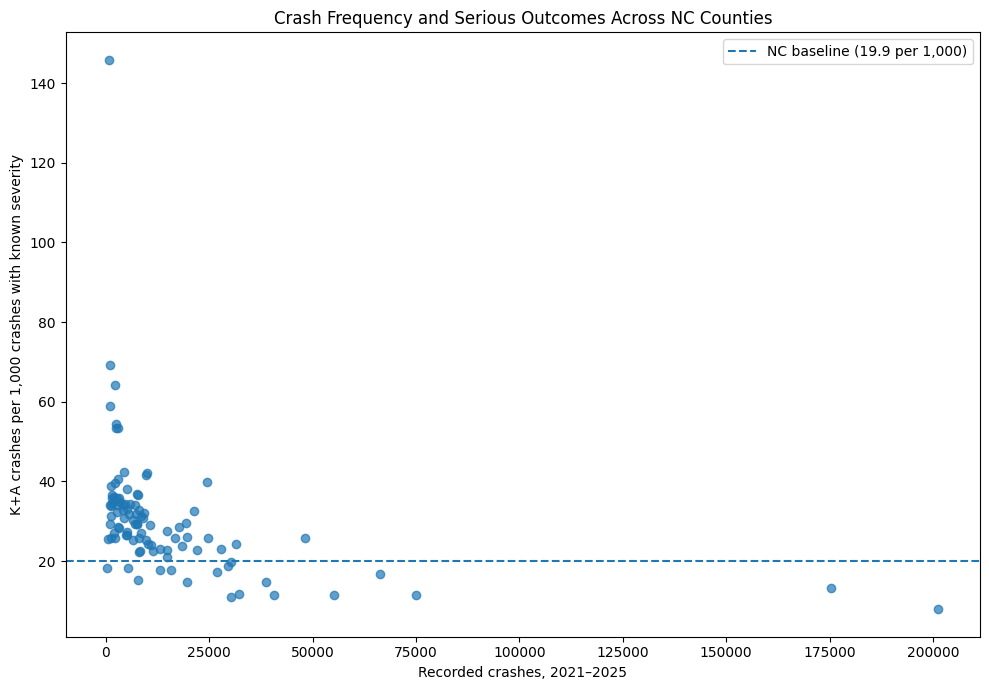

In [19]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    county_summary["crash_count"],
    county_summary["serious_rate_per_1000"],
    alpha=0.7
)

ax.axhline(
    statewide_serious_rate,
    linestyle="--",
    label=f"NC baseline ({statewide_serious_rate:.1f} per 1,000)"
)

ax.set_xlabel("Recorded crashes, 2021–2025")
ax.set_ylabel("K+A crashes per 1,000 crashes with known severity")
ax.set_title(
    "Crash Frequency and Serious Outcomes Across NC Counties"
)

ax.legend()

plt.tight_layout()
plt.show()

In [20]:
area_records = []

for area_type, area_df in df.groupby("area_type"):
    area_records.append({
        "area_type": area_type,
        "crash_count": len(area_df),
        "known_severity_count": known_severity_crash_count(area_df),
        "serious_crash_count": serious_crash_count(area_df),
        "serious_rate_per_1000": serious_rate_per_1000(area_df),
    })

area_severity_summary = pd.DataFrame(area_records)

area_severity_summary

,area_type,crash_count,known_severity_count,serious_crash_count,serious_rate_per_1000
0,Municipal/City,994277,955044,11296,11.827727
1,Rural,537865,520762,18045,34.651146
2,Unknown,2977,2856,60,21.008403


## County Rural Composition and Serious Outcomes

The statewide comparison shows that K+A outcomes are more common among
records classified as rural than among municipal/city records.

We next examine whether counties with a larger share of rural-coded
crashes also tend to have higher Serious Outcome Rates.

This analysis describes an association and does not establish that
rural classification causes more severe outcomes.

In [21]:
pearson_rural = county_analysis[
    "rural_crash_share"
].corr(
    county_analysis["serious_rate_per_1000"],
    method="pearson",
)

spearman_rural = county_analysis[
    "rural_crash_share"
].corr(
    county_analysis["serious_rate_per_1000"],
    method="spearman",
)

print(
    f"Pearson correlation: {pearson_rural:.3f}"
)

print(
    f"Spearman correlation: {spearman_rural:.3f}"
)

Pearson correlation: 0.537
Spearman correlation: 0.692


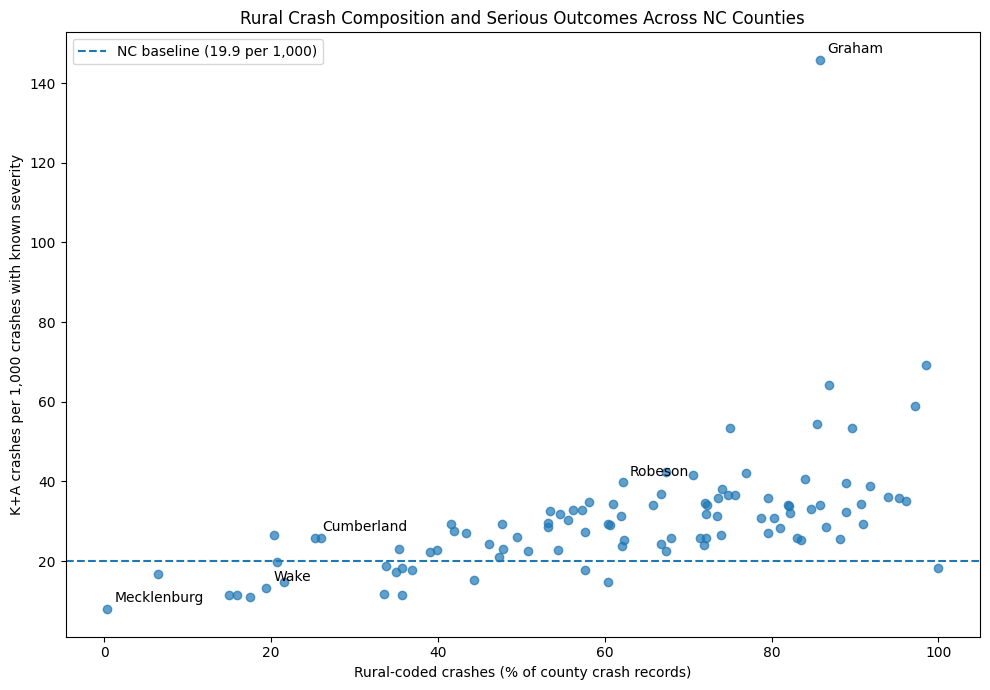

In [22]:
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    county_analysis["rural_crash_share"] * 100,
    county_analysis["serious_rate_per_1000"],
    alpha=0.7,
)

ax.axhline(
    statewide_serious_rate,
    linestyle="--",
    label=f"NC baseline ({statewide_serious_rate:.1f} per 1,000)",
)

ax.set_xlabel("Rural-coded crashes (% of county crash records)")
ax.set_ylabel(
    "K+A crashes per 1,000 crashes with known severity"
)
ax.set_title(
    "Rural Crash Composition and Serious Outcomes Across NC Counties"
)

ax.legend()
counties_to_label = [
    "Graham",
    "Mecklenburg",
    "Wake",
    "Robeson",
    "Cumberland",
]

for _, row in county_analysis[
    county_analysis["County"].isin(counties_to_label)
].iterrows():
    ax.annotate(
        row["County"],
        (
            row["rural_crash_share"] * 100,
            row["serious_rate_per_1000"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
    )
plt.tight_layout()
plt.show()

In [23]:
import geopandas as gpd

## County-Level Geographic Patterns

To compare crash frequency and serious-outcome patterns geographically,
we use 2025 U.S. Census Bureau Cartographic Boundary county polygons.

The Census geometry is used only for visualization. Crash measures are
derived from the NCDOT crash records for 2021–2025.

In [24]:
county_boundary_path = (
    PROJECT_ROOT
    / "data"
    / "external"
    / "cb_2025_us_county_500k.zip"
)

us_counties = gpd.read_file(county_boundary_path)

us_counties.shape

(3235, 13)

In [25]:
us_counties[
    [
        "STATEFP",
        "COUNTYFP",
        "GEOID",
        "NAME",
        "geometry",
    ]
].head()

,STATEFP,COUNTYFP,GEOID,NAME,geometry
0,06,085,06085,Santa Clara,"POLYGON ((-122.20265 37.36305, -122.20132 37.3..."
1,06,059,06059,Orange,"POLYGON ((-118.11464 33.74461, -118.11406 33.7..."
2,17,043,17043,DuPage,"POLYGON ((-88.26288 41.98244, -88.26288 41.986..."
3,04,027,04027,Yuma,"POLYGON ((-114.81629 32.50804, -114.81432 32.5..."
4,01,003,01003,Baldwin,"POLYGON ((-88.02858 30.22676, -88.02399 30.230..."


In [26]:
nc_boundaries = (
    us_counties.loc[
        us_counties["STATEFP"] == "37"
    ]
    .copy()
)

print(
    "NC county polygons:",
    len(nc_boundaries),
)

nc_boundaries[
    [
        "GEOID",
        "NAME",
        "geometry",
    ]
].head()

NC county polygons: 100


,GEOID,NAME,geometry
15,37039,Cherokee,"POLYGON ((-84.31749 35.02184, -84.31748 35.021..."
66,37115,Madison,"POLYGON ((-82.96221 35.79276, -82.96284 35.795..."
67,37155,Robeson,"POLYGON ((-79.46147 34.63042, -79.38133 34.718..."
68,37079,Greene,"POLYGON ((-77.82553 35.47042, -77.82537 35.476..."
69,37111,McDowell,"POLYGON ((-82.29491 35.68386, -82.29241 35.689..."


In [27]:
print(
    "Unique county names:",
    nc_boundaries["NAME"].nunique(),
)

print(
    "Duplicate county names:",
    nc_boundaries["NAME"].duplicated().sum(),
)

Unique county names: 100
Duplicate county names: 0


In [28]:
nc_county_geo = prepare_county_geodata(
    nc_boundaries,
    county_analysis,
    boundary_name_col="NAME",
)

In [30]:
print("Mapped counties:", len(nc_county_geo))

print(
    "Counties missing crash counts:",
    nc_county_geo["crash_count"].isna().sum(),
)

print(
    "Counties missing serious rates:",
    nc_county_geo["serious_rate_per_1000"].isna().sum(),
)

Mapped counties: 100
Counties missing crash counts: 0
Counties missing serious rates: 0


### Geographic Distribution of Recorded Crashes

Crash volume varies substantially across North Carolina counties. To make
geographic differences visible despite the highly skewed distribution of
county crash counts, counties are grouped into quintiles based on their
2021–2025 recorded crash totals.

This map represents **crash frequency**, not crash severity or crash risk.
Higher crash counts may reflect factors such as population, traffic volume,
road-network size, and travel activity, for which this analysis does not
currently adjust.

In [ ]:
%pip install mapclassify

In [34]:
county_crash_quintiles = pd.qcut(
    nc_county_geo["crash_count"],
    q=5,
    duplicates="drop",
)

(
    nc_county_geo
    .assign(crash_count_quintile=county_crash_quintiles)
    .groupby(
        "crash_count_quintile",
        observed=True,
    )
    .agg(
        counties=("County", "count"),
        min_crashes=("crash_count", "min"),
        max_crashes=("crash_count", "max"),
    )
)

,counties,min_crashes,max_crashes
crash_count_quintile,,,
"(333.999, 2341.6]",20,334,2320
"(2341.6, 5233.2]",20,2347,5232
"(5233.2, 8713.6]",20,5234,8488
"(8713.6, 19607.6]",20,9052,19584
"(19607.6, 201315.0]",20,19702,201315


In [35]:
crash_bins = [
    0,
    2500,
    5000,
    10000,
    20000,
    50000,
    float("inf"),
]

crash_labels = [
    "< 2.5K",
    "2.5K–5K",
    "5K–10K",
    "10K–20K",
    "20K–50K",
    "50K+",
]

nc_county_geo["crash_volume_band"] = pd.cut(
    nc_county_geo["crash_count"],
    bins=crash_bins,
    labels=crash_labels,
    right=False,
)

nc_county_geo[
    "crash_volume_band"
].value_counts(sort=False)

crash_volume_band
< 2.5K     22
2.5K–5K    15
5K–10K     28
10K–20K    16
20K–50K    14
50K+        5
Name: count, dtype: int64

In [37]:
top_volume_counties = (
    nc_county_geo
    .nlargest(10, "crash_count")
    .copy()
)

top_volume_counties[
    ["County", "crash_count"]
]

,County,crash_count
8,Mecklenburg,201315
49,Wake,175360
88,Guilford,74993
73,Forsyth,66410
77,Durham,55149
14,Cumberland,48084
92,Buncombe,40733
94,Gaston,38668
44,New Hanover,32103
98,Johnston,31527


In [ ]:
%pip install adjustText

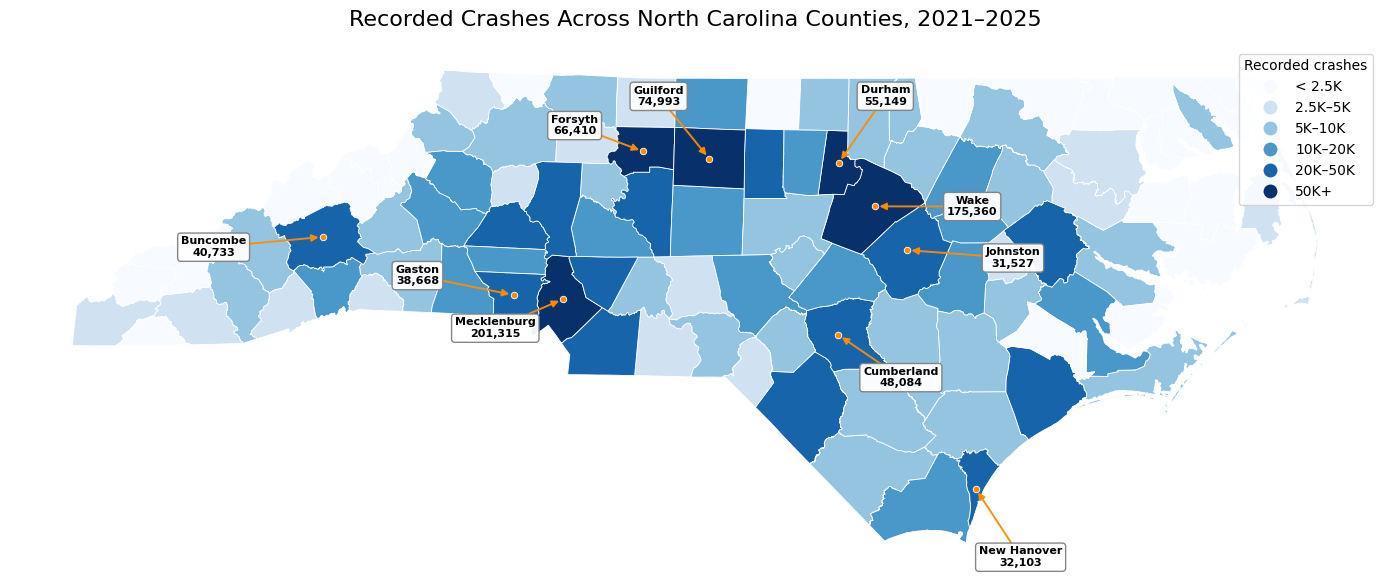

In [44]:
from adjustText import adjust_text
import numpy as np

# Number of highest-volume counties to label
n_labels = 10

counties_to_label = (
    nc_county_geo
    .nlargest(n_labels, "crash_count")
    .copy()
)

fig, ax = plt.subplots(figsize=(14, 8))

# Plot crash-volume categories
nc_county_geo.plot(
    column="crash_volume_band",
    categorical=True,
    cmap="Blues",
    linewidth=0.6,
    edgecolor="white",
    legend=True,
    legend_kwds={
        "title": "Recorded crashes",
        "loc": "upper right",
    },
    ax=ax,
)

# ---------------------------------------------------------
# Generate geographic anchor points for the selected counties
# ---------------------------------------------------------

label_points = (
    counties_to_label
    .geometry
    .representative_point()
)

target_x = label_points.x.to_numpy()
target_y = label_points.y.to_numpy()

# Center and dimensions of the NC map
minx, miny, maxx, maxy = nc_county_geo.total_bounds

map_center_x = (minx + maxx) / 2
map_center_y = (miny + maxy) / 2

map_width = maxx - minx
map_height = maxy - miny

# ---------------------------------------------------------
# Automatically place labels away from county anchors
# ---------------------------------------------------------

text_x = []
text_y = []

for x, y in zip(target_x, target_y):

    dx = x - map_center_x
    dy = y - map_center_y

    distance = np.hypot(dx, dy)

    # Avoid division by zero for a county near the map center
    if distance == 0:
        dx = 1
        dy = 1
        distance = np.sqrt(2)

    # Initial outward placement
    text_x.append(
        x + (dx / distance) * map_width * 0.060
    )

    text_y.append(
        y + (dy / distance) * map_height * 0.085
    )

# ---------------------------------------------------------
# Create text labels
# ---------------------------------------------------------

texts = []

for (_, row), x, y in zip(
    counties_to_label.iterrows(),
    text_x,
    text_y,
):
    texts.append(
        ax.text(
            x,
            y,
            f"{row['County']}\n{row['crash_count']:,}",
            ha="center",
            va="center",
            fontsize=8,
            fontweight="bold",
            zorder=5,
            bbox={
                "boxstyle": "round,pad=0.3",
                "facecolor": "white",
                "edgecolor": "gray",
                "alpha": 0.95,
            },
        )
    )

# ---------------------------------------------------------
# Resolve textbox collisions
# ---------------------------------------------------------

adjust_text(
    texts,
    ax=ax,
    expand=(1.15, 1.25),
    force_text=(0.5, 0.7),
    force_static=(0.3, 0.5),
)

# ---------------------------------------------------------
# Enforce minimum textbox-to-county distance
# ---------------------------------------------------------

# Global minimum separation based on map dimensions.
# This is applied consistently to every labeled county.
min_label_distance = 0.055 * np.hypot(
    map_width,
    map_height,
)

for text, target_x_i, target_y_i in zip(
    texts,
    target_x,
    target_y,
):

    text_x_i, text_y_i = text.get_position()

    dx = text_x_i - target_x_i
    dy = text_y_i - target_y_i

    distance = np.hypot(dx, dy)

    # If adjustText moved the label too close to the county,
    # push the label outward to maintain a visible connector.
    if distance < min_label_distance:

        if distance == 0:

            # Use direction from state center
            dx = target_x_i - map_center_x
            dy = target_y_i - map_center_y

            distance = np.hypot(dx, dy)

            if distance == 0:
                dx = 1
                dy = 1
                distance = np.sqrt(2)

        unit_x = dx / distance
        unit_y = dy / distance

        new_text_x = (
            target_x_i
            + unit_x * min_label_distance
        )

        new_text_y = (
            target_y_i
            + unit_y * min_label_distance
        )

        text.set_position(
            (new_text_x, new_text_y)
        )

# ---------------------------------------------------------
# Draw arrows after final textbox positions are known
# ---------------------------------------------------------

for text, target_x_i, target_y_i in zip(
    texts,
    target_x,
    target_y,
):

    text_x_i, text_y_i = text.get_position()

    ax.annotate(
        "",
        xy=(target_x_i, target_y_i),
        xytext=(text_x_i, text_y_i),
        arrowprops={
            "arrowstyle": "-|>",
            "color": "darkorange",
            "linewidth": 1.4,
            "alpha": 0.95,
            "mutation_scale": 10,
            "shrinkA": 12,
            "shrinkB": 3,
        },
        zorder=4,
    )

# ---------------------------------------------------------
# Mark the actual county anchor points
# ---------------------------------------------------------

ax.scatter(
    target_x,
    target_y,
    s=22,
    color="darkorange",
    edgecolor="white",
    linewidth=0.6,
    zorder=6,
)

# ---------------------------------------------------------
# Final formatting
# ---------------------------------------------------------

ax.set_title(
    "Recorded Crashes Across North Carolina Counties, 2021–2025",
    fontsize=16,
    pad=15,
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [49]:
from adjustText import adjust_text
import numpy as np


def plot_county_metric_map(
    geo_df,
    metric_col,
    category_col,
    title,
    legend_title,
    n_labels=10,
    label_metric_col=None,
    label_formatter=None,
    cmap="Blues",
    legend_loc="lower right",
    legend_bbox_to_anchor=None,
):
    """
    Plot a county-level choropleth using the standard project map style.

    Parameters
    ----------
    geo_df : GeoDataFrame
        County-level geographic data.

    metric_col : str
        Numeric metric used to determine which counties are labeled.

    category_col : str
        Categorical column used for choropleth coloring.

    title : str
        Plot title.

    legend_title : str
        Legend title.

    n_labels : int
        Number of highest-value counties to label.

    label_metric_col : str, optional
        Metric displayed in the annotation.
        Defaults to metric_col.

    label_formatter : callable, optional
        Function used to format the annotation value.

    cmap : str
        Matplotlib colormap.
    """

    if label_metric_col is None:
        label_metric_col = metric_col

    if label_formatter is None:
        label_formatter = lambda value: f"{value:,.1f}"

    counties_to_label = (
        geo_df
        .nlargest(n_labels, metric_col)
        .copy()
    )

    fig, ax = plt.subplots(figsize=(14, 8))

    # -----------------------------------------------------
    # Choropleth
    # -----------------------------------------------------

    geo_df.plot(
        column=category_col,
        categorical=True,
        cmap=cmap,
        linewidth=0.6,
        edgecolor="white",
        legend=True,
        legend_kwds={
            "title": legend_title,
            "loc": legend_loc,
            "bbox_to_anchor": legend_bbox_to_anchor,
        },
        ax=ax,
    )

    # -----------------------------------------------------
    # County anchor points
    # -----------------------------------------------------

    label_points = (
        counties_to_label
        .geometry
        .representative_point()
    )

    target_x = label_points.x.to_numpy()
    target_y = label_points.y.to_numpy()

    minx, miny, maxx, maxy = geo_df.total_bounds

    map_center_x = (minx + maxx) / 2
    map_center_y = (miny + maxy) / 2

    map_width = maxx - minx
    map_height = maxy - miny

    # -----------------------------------------------------
    # Initial automatic label placement
    # -----------------------------------------------------

    text_x = []
    text_y = []

    for x, y in zip(target_x, target_y):

        dx = x - map_center_x
        dy = y - map_center_y

        distance = np.hypot(dx, dy)

        if distance == 0:
            dx = 1
            dy = 1
            distance = np.sqrt(2)

        text_x.append(
            x + (dx / distance) * map_width * 0.060
        )

        text_y.append(
            y + (dy / distance) * map_height * 0.085
        )

    # -----------------------------------------------------
    # Text labels
    # -----------------------------------------------------

    texts = []

    for (_, row), x, y in zip(
        counties_to_label.iterrows(),
        text_x,
        text_y,
    ):

        value = label_formatter(
            row[label_metric_col]
        )

        texts.append(
            ax.text(
                x,
                y,
                f"{row['County']}\n{value}",
                ha="center",
                va="center",
                fontsize=8,
                fontweight="bold",
                zorder=5,
                bbox={
                    "boxstyle": "round,pad=0.3",
                    "facecolor": "white",
                    "edgecolor": "gray",
                    "alpha": 0.95,
                },
            )
        )

    # -----------------------------------------------------
    # Automatically resolve textbox collisions
    # -----------------------------------------------------

    adjust_text(
        texts,
        ax=ax,
        expand=(1.15, 1.25),
        force_text=(0.5, 0.7),
        force_static=(0.3, 0.5),
    )

    # -----------------------------------------------------
    # Guarantee visible connector length
    # -----------------------------------------------------

    min_label_distance = (
        0.055
        * np.hypot(
            map_width,
            map_height,
        )
    )

    for text, target_x_i, target_y_i in zip(
        texts,
        target_x,
        target_y,
    ):

        text_x_i, text_y_i = text.get_position()

        dx = text_x_i - target_x_i
        dy = text_y_i - target_y_i

        distance = np.hypot(dx, dy)

        if distance < min_label_distance:

            if distance == 0:

                dx = target_x_i - map_center_x
                dy = target_y_i - map_center_y

                distance = np.hypot(dx, dy)

                if distance == 0:
                    dx = 1
                    dy = 1
                    distance = np.sqrt(2)

            unit_x = dx / distance
            unit_y = dy / distance

            text.set_position(
                (
                    target_x_i
                    + unit_x * min_label_distance,
                    target_y_i
                    + unit_y * min_label_distance,
                )
            )

    # -----------------------------------------------------
    # Connector arrows
    # -----------------------------------------------------

    for text, target_x_i, target_y_i in zip(
        texts,
        target_x,
        target_y,
    ):

        text_x_i, text_y_i = text.get_position()

        ax.annotate(
            "",
            xy=(target_x_i, target_y_i),
            xytext=(text_x_i, text_y_i),
            arrowprops={
                "arrowstyle": "-|>",
                "color": "darkorange",
                "linewidth": 1.4,
                "alpha": 0.95,
                "mutation_scale": 10,
                "shrinkA": 12,
                "shrinkB": 3,
            },
            zorder=4,
        )

    # -----------------------------------------------------
    # County anchor markers
    # -----------------------------------------------------

    ax.scatter(
        target_x,
        target_y,
        s=22,
        color="darkorange",
        edgecolor="white",
        linewidth=0.6,
        zorder=6,
    )

    ax.set_title(
        title,
        fontsize=16,
        pad=15,
    )

    ax.set_axis_off()

    plt.tight_layout()
    plt.show()

### Geographic Pattern of Serious Crash Outcomes

Crash frequency does not necessarily correspond to crash severity.

The following map shows the number of fatal or serious-injury crashes
(K+A) per 1,000 recorded crashes with known severity in each county.

Unknown-severity crashes are excluded from the denominator. This is a
measure of the severity composition of recorded crashes, not exposure-
adjusted crash risk.

In [46]:
severity_bins = [
    0,
    10,
    20,
    30,
    40,
    60,
    float("inf"),
]

severity_labels = [
    "< 10",
    "10–20",
    "20–30",
    "30–40",
    "40–60",
    "60+",
]

nc_county_geo["serious_rate_band"] = pd.cut(
    nc_county_geo["serious_rate_per_1000"],
    bins=severity_bins,
    labels=severity_labels,
    right=False,
)

In [47]:
nc_county_geo[
    "serious_rate_band"
].value_counts(sort=False)

serious_rate_band
< 10      1
10–20    17
20–30    37
30–40    34
40–60     8
60+       3
Name: count, dtype: int64

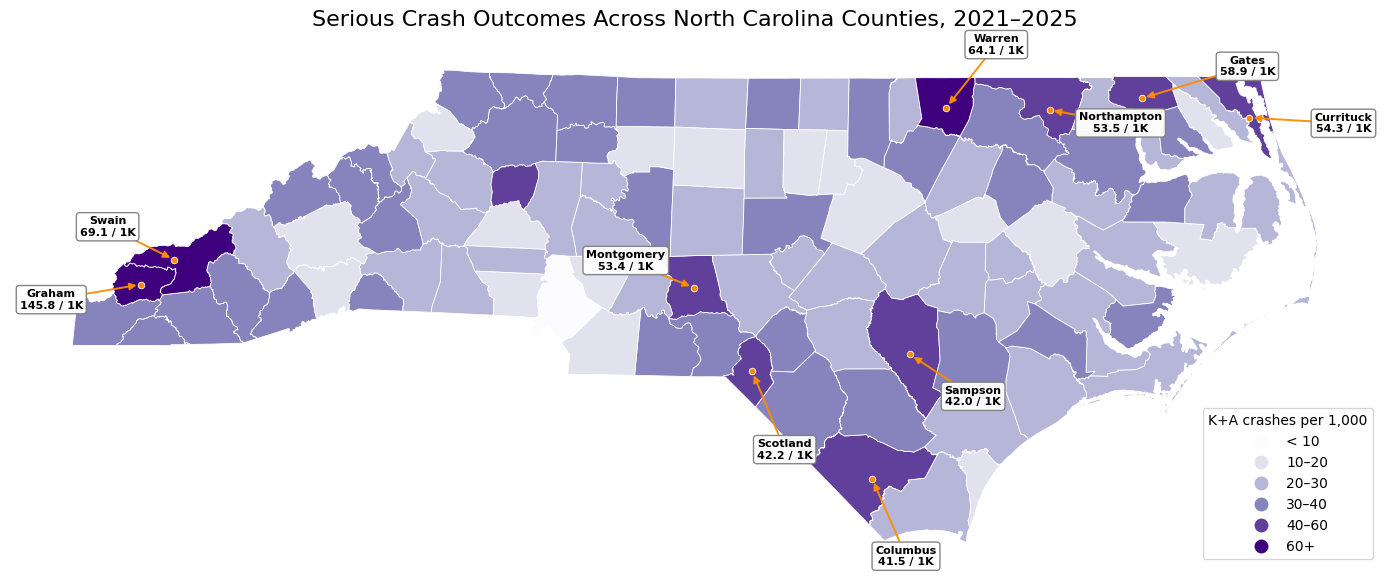

In [50]:
plot_county_metric_map(
    geo_df=nc_county_geo,
    metric_col="serious_rate_per_1000",
    category_col="serious_rate_band",
    title=(
        "Serious Crash Outcomes Across "
        "North Carolina Counties, 2021–2025"
    ),
    legend_title="K+A crashes per 1,000",
    n_labels=10,
    label_metric_col="serious_rate_per_1000",
    label_formatter=lambda x: f"{x:.1f} / 1K",
    cmap="Purples",
    legend_loc="lower right",
)

### Crash Frequency vs. Serious-Outcome Rate

The two county maps show different geographic patterns. This scatterplot
directly compares them.

Each point represents one North Carolina county. The x-axis shows total
recorded crashes during 2021–2025, while the y-axis shows fatal or
serious-injury crashes (K+A) per 1,000 crashes with known severity.

Because county crash counts are highly skewed, the x-axis uses a logarithmic
scale so that both lower- and higher-volume counties remain visible.

The statewide serious-outcome rate is shown as a reference line.

In [52]:
spearman_frequency_severity = (
    county_analysis["crash_count"]
    .corr(
        county_analysis[
            "serious_rate_per_1000"
        ],
        method="spearman",
    )
)

print(
    "Spearman correlation between county crash count "
    "and serious-outcome rate:"
)

print(
    f"{spearman_frequency_severity:.3f}"
)

Spearman correlation between county crash count and serious-outcome rate:
-0.656


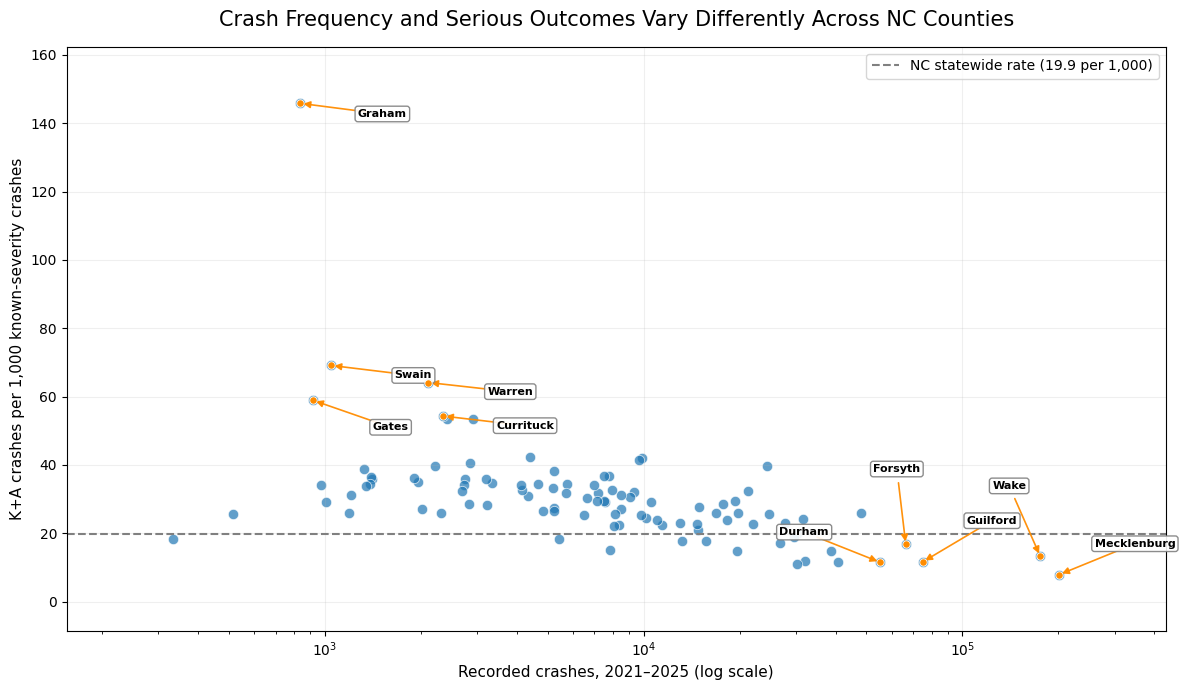

In [55]:
from adjustText import adjust_text
import numpy as np

# ---------------------------------------------------------
# Counties to highlight
# ---------------------------------------------------------

n_volume_labels = 5
n_severity_labels = 5

high_volume = (
    county_analysis
    .nlargest(n_volume_labels, "crash_count")
)

high_severity = (
    county_analysis
    .nlargest(
        n_severity_labels,
        "serious_rate_per_1000",
    )
)

counties_to_label = (
    pd.concat(
        [
            high_volume,
            high_severity,
        ]
    )
    .drop_duplicates(subset="County")
    .copy()
)

# ---------------------------------------------------------
# Statewide serious-outcome baseline
# ---------------------------------------------------------

statewide_serious_rate = serious_rate_per_1000(df)

# ---------------------------------------------------------
# Scatter plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

ax.scatter(
    county_analysis["crash_count"],
    county_analysis["serious_rate_per_1000"],
    s=55,
    alpha=0.70,
    edgecolor="white",
    linewidth=0.6,
)

ax.set_xscale("log")

ax.axhline(
    statewide_serious_rate,
    linestyle="--",
    linewidth=1.5,
    color="gray",
    label=(
        f"NC statewide rate "
        f"({statewide_serious_rate:.1f} per 1,000)"
    ),
)

# Add a little breathing room so edge labels do not get cut off
ax.margins(x=0.12, y=0.12)

# ---------------------------------------------------------
# Build initial label positions
# Use inward placement so labels near edges start inside
# the plotting area rather than outside it.
# ---------------------------------------------------------

x_all = county_analysis["crash_count"].to_numpy()
y_all = county_analysis["serious_rate_per_1000"].to_numpy()

log_x_all = np.log10(x_all)
log_x_center = np.median(log_x_all)
y_center = np.median(y_all)

target_x = counties_to_label["crash_count"].to_numpy()
target_y = counties_to_label["serious_rate_per_1000"].to_numpy()
target_log_x = np.log10(target_x)

texts = []

for (_, row), x, y, lx in zip(
    counties_to_label.iterrows(),
    target_x,
    target_y,
    target_log_x,
):
    # If point is on right side, place label left.
    # If point is on left side, place label right.
    x_direction = -1 if lx > log_x_center else 1

    # If point is on upper side, place label down.
    # If point is on lower side, place label up.
    y_direction = -1 if y > y_center else 1

    x_text = 10 ** (lx + x_direction * 0.10)
    y_text = y + y_direction * 4.5

    texts.append(
        ax.text(
            x_text,
            y_text,
            row["County"],
            fontsize=8,
            fontweight="bold",
            bbox={
                "boxstyle": "round,pad=0.25",
                "facecolor": "white",
                "edgecolor": "gray",
                "alpha": 0.90,
            },
            zorder=5,
        )
    )

# ---------------------------------------------------------
# Resolve overlaps
# ---------------------------------------------------------

adjust_text(
    texts,
    ax=ax,
    expand=(1.15, 1.25),
    force_text=(0.7, 0.9),
    force_static=(0.3, 0.5),
    only_move={
        "text": "xy",
        "static": "xy",
        "explode": "xy",
        "pull": "xy",
    },
)

# Make sure transforms are fully updated before measuring distances
fig.canvas.draw()

# ---------------------------------------------------------
# Enforce minimum text-to-point distance in DISPLAY SPACE
# ---------------------------------------------------------

# Minimum separation between each labeled point and its textbox anchor,
# measured in screen pixels.
min_display_distance = 70

# Reference center in display space for fallback direction
center_display = ax.transData.transform(
    (10 ** log_x_center, y_center)
)

for text, x_pt, y_pt in zip(
    texts,
    target_x,
    target_y,
):
    # Current label position in data coordinates
    x_text, y_text = text.get_position()

    # Convert both point and label anchor to display coordinates
    point_display = ax.transData.transform((x_pt, y_pt))
    text_display = ax.transData.transform((x_text, y_text))

    dx = text_display[0] - point_display[0]
    dy = text_display[1] - point_display[1]

    distance = np.hypot(dx, dy)

    # If the label is too close to the point, push it farther away
    if distance < min_display_distance:

        if distance == 0:
            dx = point_display[0] - center_display[0]
            dy = point_display[1] - center_display[1]
            distance = np.hypot(dx, dy)

            if distance == 0:
                dx = 1
                dy = 1
                distance = np.sqrt(2)

        unit_x = dx / distance
        unit_y = dy / distance

        new_text_display = (
            point_display
            + np.array([unit_x, unit_y]) * min_display_distance
        )

        # Convert back to data coordinates and update the text position
        new_text_data = ax.transData.inverted().transform(
            new_text_display
        )

        text.set_position(tuple(new_text_data))

# Re-draw after moving labels
fig.canvas.draw()

# ---------------------------------------------------------
# Draw arrows manually
# ---------------------------------------------------------

for text, x_pt, y_pt in zip(
    texts,
    target_x,
    target_y,
):
    x_text, y_text = text.get_position()

    ax.annotate(
        "",
        xy=(x_pt, y_pt),
        xytext=(x_text, y_text),
        arrowprops={
            "arrowstyle": "-|>",
            "color": "darkorange",
            "linewidth": 1.2,
            "alpha": 0.95,
            "mutation_scale": 10,
            "shrinkA": 10,
            "shrinkB": 2,
        },
        zorder=4,
    )

# Highlight the actual labeled county points
ax.scatter(
    target_x,
    target_y,
    s=28,
    color="darkorange",
    edgecolor="white",
    linewidth=0.6,
    zorder=6,
)

# ---------------------------------------------------------
# Final formatting
# ---------------------------------------------------------

ax.set_title(
    "Crash Frequency and Serious Outcomes Vary Differently Across NC Counties",
    fontsize=15,
    pad=15,
)

ax.set_xlabel(
    "Recorded crashes, 2021–2025 (log scale)",
    fontsize=11,
)

ax.set_ylabel(
    "K+A crashes per 1,000 known-severity crashes",
    fontsize=11,
)

ax.grid(alpha=0.20)
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

### Serious Outcomes by Rural vs. Municipal/City Crash Location

The county-level analysis suggests that geography may help explain some of
the variation in serious crash outcomes.

This comparison examines recorded crashes coded as rural versus
municipal/city. The metric is the number of fatal or serious-injury crashes
(K+A) per 1,000 crashes with known severity.

This comparison is descriptive and does not account for exposure such as
vehicle miles traveled, traffic volume, roadway design, or emergency
response access.

In [56]:
area_type_summary = (
    df.loc[
        df["area_type"].isin(
            ["Rural", "Municipal/City"]
        )
    ]
    .groupby("area_type")
    .apply(
        serious_rate_per_1000,
        include_groups=False,
    )
    .rename("serious_rate_per_1000")
    .reset_index()
)

area_type_summary

,area_type,serious_rate_per_1000
0,Municipal/City,11.827727
1,Rural,34.651146


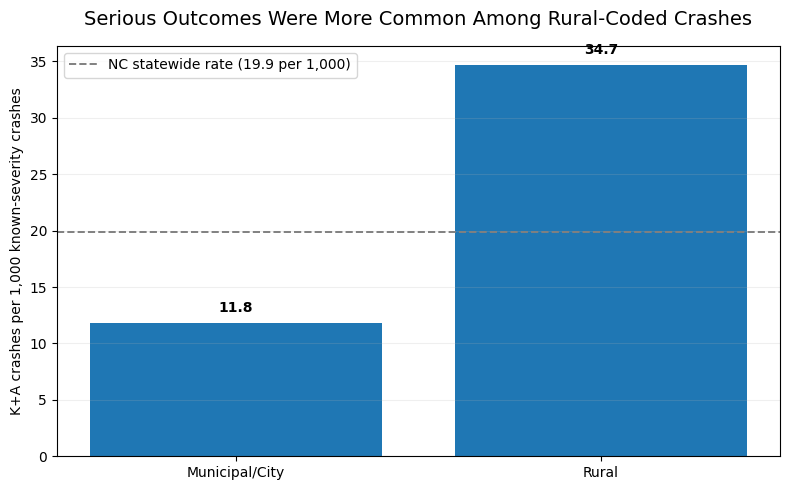

In [57]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    area_type_summary["area_type"],
    area_type_summary["serious_rate_per_1000"],
)

for bar, value in zip(
    bars,
    area_type_summary["serious_rate_per_1000"],
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.7,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

ax.axhline(
    statewide_serious_rate,
    linestyle="--",
    linewidth=1.4,
    color="gray",
    label=(
        f"NC statewide rate "
        f"({statewide_serious_rate:.1f} per 1,000)"
    ),
)

ax.set_title(
    "Serious Outcomes Were More Common Among Rural-Coded Crashes",
    fontsize=14,
    pad=15,
)

ax.set_ylabel(
    "K+A crashes per 1,000 known-severity crashes"
)

ax.set_xlabel("")

ax.legend()

ax.grid(
    axis="y",
    alpha=0.20,
)

plt.tight_layout()
plt.show()

### Rural vs. Municipal/City Serious Outcomes

Among recorded crashes with known severity:

- Municipal/City: **11.8 K+A crashes per 1,000**
- Rural: **34.7 K+A crashes per 1,000**

The serious-outcome rate among rural-coded crashes was therefore about
**2.9 times** the municipal/city-coded rate.

This is a descriptive comparison and does not adjust for exposure,
roadway characteristics, traffic volume, or other factors.

In [58]:
pearson_rural = (
    county_analysis["rural_crash_share"]
    .corr(
        county_analysis["serious_rate_per_1000"],
        method="pearson",
    )
)

spearman_rural = (
    county_analysis["rural_crash_share"]
    .corr(
        county_analysis["serious_rate_per_1000"],
        method="spearman",
    )
)

print(
    f"Pearson correlation: {pearson_rural:.3f}"
)

print(
    f"Spearman correlation: {spearman_rural:.3f}"
)

Pearson correlation: 0.537
Spearman correlation: 0.692


### Rural Crash Share vs. Serious-Outcome Rate

Counties differ substantially in how much of their recorded crash activity
is coded as rural.

This plot examines whether counties with a larger rural share of recorded
crashes also tend to have higher fatal or serious-injury (K+A) rates among
crashes with known severity.

Each point represents one North Carolina county. This is a descriptive
association and does not establish that rural location itself causes more
serious outcomes.

Pearson correlation: 0.537
Spearman correlation: 0.692


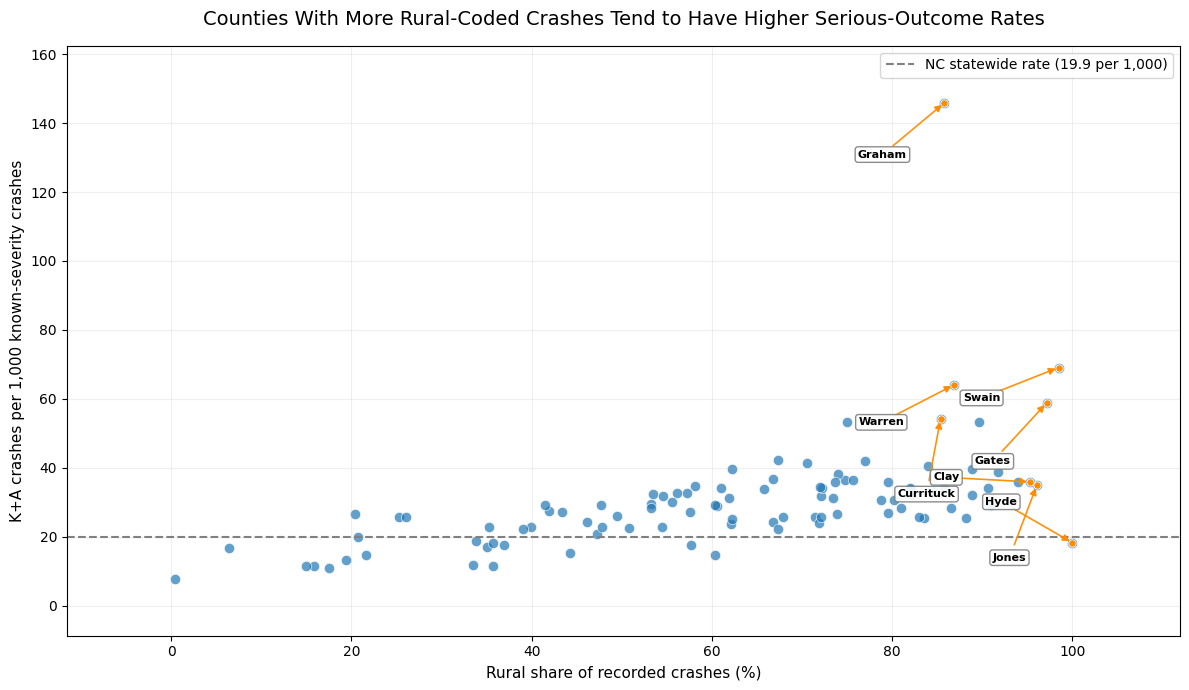

In [59]:
from adjustText import adjust_text
import numpy as np

# ---------------------------------------------------------
# Counties to highlight
# ---------------------------------------------------------

n_rural_labels = 5
n_severity_labels = 5

high_rural_share = (
    county_analysis
    .nlargest(
        n_rural_labels,
        "rural_crash_share",
    )
)

high_severity = (
    county_analysis
    .nlargest(
        n_severity_labels,
        "serious_rate_per_1000",
    )
)

counties_to_label = (
    pd.concat(
        [
            high_rural_share,
            high_severity,
        ]
    )
    .drop_duplicates(subset="County")
    .copy()
)

# ---------------------------------------------------------
# Correlations
# ---------------------------------------------------------

pearson_rural = (
    county_analysis["rural_crash_share"]
    .corr(
        county_analysis["serious_rate_per_1000"],
        method="pearson",
    )
)

spearman_rural = (
    county_analysis["rural_crash_share"]
    .corr(
        county_analysis["serious_rate_per_1000"],
        method="spearman",
    )
)

print(
    f"Pearson correlation: {pearson_rural:.3f}"
)

print(
    f"Spearman correlation: {spearman_rural:.3f}"
)

# ---------------------------------------------------------
# Scatter plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

x_values = (
    county_analysis["rural_crash_share"] * 100
)

y_values = (
    county_analysis["serious_rate_per_1000"]
)

ax.scatter(
    x_values,
    y_values,
    s=55,
    alpha=0.70,
    edgecolor="white",
    linewidth=0.6,
)

# Statewide serious-outcome baseline
ax.axhline(
    statewide_serious_rate,
    linestyle="--",
    linewidth=1.5,
    color="gray",
    label=(
        f"NC statewide rate "
        f"({statewide_serious_rate:.1f} per 1,000)"
    ),
)

ax.margins(
    x=0.12,
    y=0.12,
)

# ---------------------------------------------------------
# Selected county coordinates
# ---------------------------------------------------------

target_x = (
    counties_to_label["rural_crash_share"]
    .to_numpy()
    * 100
)

target_y = (
    counties_to_label[
        "serious_rate_per_1000"
    ]
    .to_numpy()
)

x_center = np.median(x_values)
y_center = np.median(y_values)

# ---------------------------------------------------------
# Initial label positions
# ---------------------------------------------------------

texts = []

for (_, row), x_pt, y_pt in zip(
    counties_to_label.iterrows(),
    target_x,
    target_y,
):
    # Place labels inward relative to the plot center
    x_direction = (
        -1
        if x_pt > x_center
        else 1
    )

    y_direction = (
        -1
        if y_pt > y_center
        else 1
    )

    x_text = (
        x_pt
        + x_direction * 5
    )

    y_text = (
        y_pt
        + y_direction * 5
    )

    texts.append(
        ax.text(
            x_text,
            y_text,
            row["County"],
            fontsize=8,
            fontweight="bold",
            bbox={
                "boxstyle": "round,pad=0.25",
                "facecolor": "white",
                "edgecolor": "gray",
                "alpha": 0.90,
            },
            zorder=5,
        )
    )

# ---------------------------------------------------------
# Resolve label collisions
# ---------------------------------------------------------

adjust_text(
    texts,
    ax=ax,
    expand=(1.15, 1.25),
    force_text=(0.7, 0.9),
    force_static=(0.3, 0.5),
    only_move={
        "text": "xy",
        "static": "xy",
        "explode": "xy",
        "pull": "xy",
    },
)

fig.canvas.draw()

# ---------------------------------------------------------
# Enforce minimum textbox-to-point distance
# in screen/display coordinates
# ---------------------------------------------------------

min_display_distance = 70

center_display = ax.transData.transform(
    (
        x_center,
        y_center,
    )
)

for text, x_pt, y_pt in zip(
    texts,
    target_x,
    target_y,
):
    x_text, y_text = text.get_position()

    point_display = ax.transData.transform(
        (x_pt, y_pt)
    )

    text_display = ax.transData.transform(
        (x_text, y_text)
    )

    dx = (
        text_display[0]
        - point_display[0]
    )

    dy = (
        text_display[1]
        - point_display[1]
    )

    distance = np.hypot(
        dx,
        dy,
    )

    if distance < min_display_distance:

        if distance == 0:

            dx = (
                point_display[0]
                - center_display[0]
            )

            dy = (
                point_display[1]
                - center_display[1]
            )

            distance = np.hypot(
                dx,
                dy,
            )

            if distance == 0:
                dx = 1
                dy = 1
                distance = np.sqrt(2)

        unit_x = dx / distance
        unit_y = dy / distance

        new_text_display = (
            point_display
            + np.array(
                [
                    unit_x,
                    unit_y,
                ]
            )
            * min_display_distance
        )

        new_text_data = (
            ax.transData
            .inverted()
            .transform(
                new_text_display
            )
        )

        text.set_position(
            tuple(new_text_data)
        )

fig.canvas.draw()

# ---------------------------------------------------------
# Draw arrows after final label positions
# ---------------------------------------------------------

for text, x_pt, y_pt in zip(
    texts,
    target_x,
    target_y,
):
    x_text, y_text = text.get_position()

    ax.annotate(
        "",
        xy=(x_pt, y_pt),
        xytext=(x_text, y_text),
        arrowprops={
            "arrowstyle": "-|>",
            "color": "darkorange",
            "linewidth": 1.2,
            "alpha": 0.95,
            "mutation_scale": 10,
            "shrinkA": 10,
            "shrinkB": 2,
        },
        zorder=4,
    )

# Highlight labeled counties
ax.scatter(
    target_x,
    target_y,
    s=28,
    color="darkorange",
    edgecolor="white",
    linewidth=0.6,
    zorder=6,
)

# ---------------------------------------------------------
# Formatting
# ---------------------------------------------------------

ax.set_title(
    "Counties With More Rural-Coded Crashes Tend to Have Higher Serious-Outcome Rates",
    fontsize=14,
    pad=15,
)

ax.set_xlabel(
    "Rural share of recorded crashes (%)",
    fontsize=11,
)

ax.set_ylabel(
    "K+A crashes per 1,000 known-severity crashes",
    fontsize=11,
)

ax.grid(alpha=0.20)

ax.legend(
    frameon=True,
)

plt.tight_layout()
plt.show()